<a href="https://colab.research.google.com/github/mtfehl/BSE/blob/main/Data_Sci_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Outline/Checklist**
--------------------------------------
* Introduce our prediction problem

  * What are we attempting to predict?
  * Do we have any hypotheses coming into this? Any previous research we read about?
  * Implications of our prediction -- why do we care about what we're predicting? how is it relevant?
  * is our prediction problem one of regression or classification (what kind of outcome variable are we predicting?)
--------------------------------------
* Discuss dataset

  *   Limitations, problems, challenges
  *   Discussion of dimensionality
  *   Transformations of variables
  *   If there exists previous research, discuss theory & ideas
  *   Missing data? If so, how do we handle it? Why do we choose to handle it in this way?
--------------------------------------
*  Variable selection

   *   What method did we pick? why? did we need to reduce dimensions?
   *   discuss idea behind dimensionality, the advantage of choosing lasso/ridge/PLS (if needed). could we do best subset selection (very few p)?
   *   did we decide to first do PCA to reduce down into latent components, then choose variables? why or why not?
--------------------------------------
* Data exploration

  * discuss distributions, behaviors, relationships of variables
  * any interesting patterns? anything we notice that might not have expected? things we expected to see? anything supporting/negating our hypotheses?
  * data viz -- show distribution, relationships
  * what are our significant variables? how do we decide which are significant? (ties back into variable selection). Maybe some are important for one model, but not another.
  * did we transform any variables? why or why not? any issues with collinearity?
--------------------------------------
* Model building

  * Discuss each model we're running, the assumptions the model takes, what its doing to our dataset, the trade-off b/w variance and bias, etc
  * How do we define our loss function (MSE for numerical, cross-entropy for categorical) How are we measuring our loss function? Do we expect to see a low loss function value for a certain model, relative to another?
  * using different measures of performance: k-fold CV, different IC. difference b/w measuring w/ IC versus CV?
  * what happens as we increase model complexity? at what point do we lose interpretability? do the more complex models always outpeform the less complex models? why or why not?
--------------------------------------
* Results

  * performances of all our models against each other, which is the 'best'
      * any trade-offs for a decrease of MSE? should we prefer one model to the other if more complexity perhaps only leads to marginal decreases in MSE?
  * limitations of our prediction -- if our data was missing, incomplete, variables not included/hard to measure
      * would their inclusion necessarily improve our results?
  

#Project info
description of project

## Data Exploration
explanation of data set

### Load in libraries

In [ ]:
# install.packages('tidyverse')
# install.packages('skimr')
# install.packages('janitor')
# install.packages('ranger')
# install.packages('corrplot')
library(tidyverse) # tidyverse universe
library(skimr)
library(janitor)
library(ranger)
library(corrplot)

### Load in data

In [ ]:
car_crash_usa <- read_csv("https://media.githubusercontent.com/media/mtfehl/BSE/refs/heads/main/DS/project/data/car_crash_usa.csv")

### exploring data
exploring data: summary, cleaning, distributions, relationships, limitations

In [ ]:
head(car_crash_usa)

In [ ]:
glimpse(car_crash_usa)

In [ ]:
summary(car_crash_usa)

In [ ]:
# Missings
car_crash_usa %>%
  summarise(across(everything(), ~sum(is.na(.)))) %>%
  pivot_longer(everything(),
               names_to = "variable",
               values_to = "n_missing") %>%
  arrange(desc(n_missing))

In [ ]:
# % missing
car_crash_usa %>%
  summarise(across(everything(), ~mean(is.na(.))*100)) %>%
  pivot_longer(cols = everything(),
               names_to = "variable",
               values_to = "pct_missing") %>%
  arrange(desc(pct_missing))

In [ ]:
car_crash_usa %>%
  count(INJ_SEVNAME) %>%
  ggplot(aes(x = reorder(INJ_SEVNAME, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(title = "Distribution of Injury Severity",
       x = "Injury Severity", y = "Count")


# Cleaning

## PER_TYP
type of person involved in crash -- here we decide to only keep drivers to account for endogenity issues

In [ ]:
car_crash_usa <- car_crash_usa %>%
  filter(PER_TYP==1)

## INJ_SEV
outcome variable of interest -- the injury severity of the driver involved in the crash

*   this initially had issues of being highly unbalanced -- there was levels from 1-8, with over 45% of obs being "fatal"
*   thus, there would be an issue that our estimates of the outcome variable would be very highly biased towards fatal outcomes since most of our data would be trained on that. this would become very apparent and troublesome if our random training split contained mostly "fatal" outcomes, and then we used compared those to our test split that does not account for much "fatal" outcomes. (**rewrite this better**)



In [ ]:
glimpse(car_crash_usa$INJ_SEV)

In [ ]:
# Visualize distribution of outcome var: INJ_SEV
car_crash_usa %>%
  count(INJ_SEVNAME) %>%
  ggplot(aes(x = reorder(INJ_SEVNAME, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(title = "Distribution of Injury Severity",
       x = "Injury Severity", y = "Count")

In [ ]:
# mutate mapping -> filter out Unknown/Missing -> set factor levels (exclude Unknown/Missing)
car_crash_usa <- car_crash_usa %>%
  mutate(
    INJ_SEV = case_when(
      INJ_SEV == 4 ~ "Dead",
      INJ_SEV %in% c(1, 2, 3) ~ "Injured",
      INJ_SEV == 0 ~ "No Injury",
      TRUE ~ "Unknown/Missing"
    )
  ) %>%
  filter(INJ_SEV != "Unknown/Missing") %>%
  mutate(INJ_SEV = factor(INJ_SEV, levels = c("No Injury", "Injured", "Dead")))

In [ ]:
# 1. Generate the frequency table for the modified inj_sev column
severity_counts <- car_crash_usa %>%
  group_by(INJ_SEV) %>%
  summarise(
    Count = n(),
    Percentage = n() / nrow(car_crash_usa) * 100
  ) %>%
  arrange(INJ_SEV)

severity_counts

## VE_TOTAL
total # vehicles involved in the crash

In [ ]:
# Outlier check for VE_TOTAL
x <- car_crash_usa$VE_TOTAL[!is.na(car_crash_usa$VE_TOTAL)]

q1  <- quantile(x, 0.25)
q3  <- quantile(x, 0.75)
iqr <- q3 - q1
lower <- q1 - 1.5 * iqr
upper <- q3 + 1.5 * iqr

cat("Lower fence:", lower, "\n")
cat("Upper fence:", upper, "\n")
cat("Number of outliers:", sum(x < lower | x > upper), "\n")

# Boxplot for VE_TOTAL
boxplot(car_crash_usa$VE_TOTAL,
        main = "Boxplot of VE_TOTAL",
        ylab = "VE_TOTAL",
        col = "lightgray")

table(car_crash_usa$VE_TOTAL)
sort(table(car_crash_usa$VE_TOTAL), decreasing = TRUE)

## HOUR
hour of day crash occurred

In [ ]:
#HOUR_ Replace missing HOUR values (coded as 99) in the dataset
median_hour <- median(car_crash_usa$HOUR[car_crash_usa$HOUR != 99])
print(median_hour)
car_crash_usa$HOUR[car_crash_usa$HOUR == 99] <- median_hour

# Cyclic encoding of HOUR using sine and cosine
# HOUR of day (0–23)
car_crash_usa$HOUR_SIN  <- sin(2 * pi * car_crash_usa$HOUR / 24)
car_crash_usa$HOUR_COS  <- cos(2 * pi * car_crash_usa$HOUR / 24)

## DAY
day of the week crash occurred

In [ ]:
# Cyclic encoding of DAYusing sine and cosine
# DAY of month (1–31)
car_crash_usa$DAY_SIN   <- sin(2 * pi * car_crash_usa$DAY / 31)
car_crash_usa$DAY_COS   <- cos(2 * pi * car_crash_usa$DAY / 31)

## ROUTE
type of roadway crash occurred on

In [ ]:
car_crash_usa <- car_crash_usa %>%
  mutate(ROUTE = factor(ROUTE))


## HARM_EV
description

In [ ]:
car_crash_usa$HARM_EV  <- factor(car_crash_usa$HARM_EV)


## MAN_COLL
manner of collision between vehicle(s)

In [ ]:
car_crash_usa$MAN_COLL <- factor(car_crash_usa$MAN_COLL)

## RUR_URB
whether the crash occurred in a rural or urban area

In [ ]:
car_crash_usa$RUR_URB  <- factor(car_crash_usa$RUR_URB)

## LGT_COND
light conditions during time of crash

In [ ]:
# We collapse detailed light codes into a smaller number of interpretable categories:
#   - daylight
#   - dark_no_lights
#   - dark_lit
#   - dark_unknown (known to be dark, lighting unknown)
#   - twilight (dawn + dusk)
#   - unknown (other/missing/unspecified)

car_crash_usa <- car_crash_usa %>%
  mutate(
    LGT_SIMPLE = case_when(
      LGT_COND == 1 ~ "daylight",
      LGT_COND == 2 ~ "dark_no_lights",
      LGT_COND == 3 ~ "dark_lit",
      LGT_COND == 6 ~ "dark_unknown",
      LGT_COND %in% c(4, 5) ~ "twilight",      # dawn + dusk
      LGT_COND %in% c(7, 8, 9) ~ "unknown",
      TRUE ~ "unknown"
    ) %>%
      factor(levels = c(
        "daylight", "dark_no_lights", "dark_lit",
        "dark_unknown", "twilight", "unknown"
      ))
  )

# Check distribution of new light categories
car_crash_usa %>%
  tabyl(LGT_SIMPLE) %>%
  adorn_pct_formatting(digits = 2)
# 7, 8, 9 are unknowns/other - so treat as missing

## WEATHER
weather conditions during crash

In [ ]:
# We group weather codes based on visibility and road friction:
#   - good_visibility: clear or cloudy
#   - precipitation: rain, mist, sleet, snow, freezing rain
#   - low_visibility: fog, blowing snow/dirt, severe crosswinds
#   - unknown: not reported / unknown / everything else

car_crash_usa <- car_crash_usa %>%
  mutate(
    WEATHER_SIMPLE = case_when(
      WEATHER %in% c(1, 10) ~ "good_visibility",        # clear, cloudy
      WEATHER %in% c(2, 3, 4, 5, 12) ~ "precipitation", # rain, mist, sleet, snow, freezing rain
      WEATHER %in% c(6, 7, 8, 11) ~ "low_visibility",   # fog, blowing dirt/snow, crosswinds
      WEATHER %in% c(98, 99) ~ "unknown",
      TRUE ~ "unknown"
    ) %>%
      factor(levels = c("good_visibility", "precipitation",
                        "low_visibility", "unknown"))
  )


In [ ]:
# Check distribution of new weather categories
car_crash_usa %>%
  tabyl(WEATHER_SIMPLE) %>%
  adorn_pct_formatting(digits = 2)

## VPICBODYCLASSNAME
vehicle body class

In [ ]:
# We collapse detailed vehicle body types into:
#   - passenger_car: sedan, hatchback, coupe, wagon, convertible, roadster
#   - suv: SUV/MPV, CUV, SUT
#   - motorcycle: all motorcycle subtypes
#   - truck: pickups, vans, heavy trucks, buses, commercial road vehicles
#   - other: rare/special/off-road body types
#   - unknown: explicitly "Unknown" or "Not Reported"

car_crash_usa <- car_crash_usa %>%
  mutate(
    BODYCLASS_SIMPLE = case_when(

      # 1. Passenger cars
      VPICBODYCLASSNAME %in% c(
        "Sedan/Saloon",
        "Hatchback/Liftback/Notchback",
        "Coupe",
        "Wagon",
        "Convertible/Cabriolet",
        "Roadster"
      ) ~ "passenger_car",

      # 2. SUVs / CUVs / SUT
      VPICBODYCLASSNAME %in% c(
        "Sport Utility Vehicle (SUV)/Multi-Purpose Vehicle (MPV)",
        "Crossover Utility Vehicle (CUV)",
        "Sport Utility Truck (SUT)"
      ) ~ "suv",

      # 3. Motorcycles (all types)
      grepl("^Motorcycle", VPICBODYCLASSNAME) ~ "motorcycle",

      # 4. Trucks / vans / buses / commercial road vehicles
      VPICBODYCLASSNAME %in% c(
        "Pickup",
        "Minivan",
        "Van",
        "Cargo Van",
        "Step Van / Walk-in Van",
        "Truck",
        "Truck-Tractor",
        "Bus",
        "Bus - School Bus",
        "Shuttle Bus",
        "Transit Bus",
        "Motorhome",
        "Ambulance",
        "Fire Apparatus",
        "Incomplete - Commercial Chassis",
        "Incomplete - Chassis Cab (Single Cab)",
        "Incomplete - Chassis Cab (Double Cab)",
        "Incomplete - Chassis Cab (Number of Cab Unknown)",
        "Incomplete - School Bus Chassis",
        "Incomplete - Motor Home Chassis",
        "Incomplete - Bus Chassis"
      ) ~ "truck",

      # 5. Unknown vehicle type
      VPICBODYCLASSNAME %in% c("Unknown", "Not Reported", "Incomplete") ~ "unknown",

      # 6. Everything else → other
      TRUE ~ "other" # off-road, farm equipment, golf carts, snowmobiles, street sweeper, etc.
    ) %>%
      factor(levels = c("passenger_car", "suv", "motorcycle", "truck", "other", "unknown"))
  )

In [ ]:
# Check distribution of new body class categories
car_crash_usa %>%
  tabyl(BODYCLASS_SIMPLE) %>%
  adorn_pct_formatting(digits = 2)

## GVWR/WEIGHT


In [ ]:
# merge unknowns into one category
car_crash_usa <- car_crash_usa %>%
  mutate(GVWR_TO = case_when(
    GVWR_TO %in% c(98, 99) ~ 99,       # recode to combine unknowns
    TRUE ~ GVWR_TO),                   # keep rest the same
         GVWR_TONAME = case_when(
   GVWR_TO == 99 ~ "Unknown",
   TRUE ~ GVWR_TONAME)
   ) %>%
  mutate(GVWR_TO = factor(GVWR_TO))

In [ ]:
## merge gvwr_from + gvwr_to ? since they both are just the bounds for the weight
car_crash_usa %>%
  count(GVWR_FROM, GVWR_TO) %>%
  mutate(prop = round(n/sum(n), 4)*100) %>%
  arrange(desc(n))
# perhaps the conservative choice to keep only the upperbounds (heavier bound)
# why? misclassifying a heavier vehicle as a lighter class biases estimates downward
# notice in our table: very small prop with a range different for lower+upper bound
car_crash_usa <- car_crash_usa %>%
  mutate(WEIGHT = factor(GVWR_TONAME)) %>%
  select(-GVWR_FROM, -GVWR_TO, -GVWR_TONAME, -GVWR_FROMNAME)

In [ ]:
### should we then convert WEIGHT into its approriate dbl value, or keep it as factor ?
# like for interaction of F = MA, it would make sense to do dbl * dbl? versus fctr*dbl?


## TRAV_SP

In [ ]:
car_crash_usa <- car_crash_usa %>%
  mutate(TRAV_SP = case_when(
    TRAV_SP > 997 ~ NA,       # recode to combine unknowns
    TRUE ~ TRAV_SP))

## VSPD_LIM

In [ ]:
car_crash_usa <- car_crash_usa %>%
  mutate(VSPD_LIM = case_when(
    VSPD_LIM > 80 ~ NA,
    TRUE ~ VSPD_LIM))

car_crash_usa %>%
  count(VSPD_LIM) # 0 speed limit ??? parking?

## ROLLOVER

In [ ]:
# ROLLOVER + ROLINLOCNAME
# first -- we combine "unknown" and "not applicable"
car_crash_usa <- car_crash_usa %>%
  mutate(ROLINLOCNAME = case_when(
    ROLINLOCNAME %in% c("Not Applicable", "Unknown") ~ "Unknown",
    TRUE ~ ROLINLOCNAME),
         ROLLOVER = case_when(
    ROLINLOCNAME == "Unknown" ~ 8,       # combine two unknown w/ different factors as both "unknown"
    TRUE ~ ROLLOVER),
          ROLLOVER = factor(ROLLOVER))

# second -- we create ROLINLOCNAME as fctr and drop ROLLOVER var
car_crash_usa <- car_crash_usa %>%
  mutate(ROLLOVER = factor(ROLINLOCNAME)) %>%
  select(-ROLINLOCNAME)

car_crash_usa %>%
  count(ROLLOVER)

## IMPACT1

In [ ]:
# IMPACT1
car_crash_usa <- car_crash_usa %>%
  mutate(IMPACT1NAME = case_when(
    IMPACT1 %in% c(98, 99) ~ "Unknown",       # recode to combine unknowns
    TRUE ~ IMPACT1NAME),                      # keep rest the same
  IMPACT1 = factor(IMPACT1NAME)) %>%
    select(-IMPACT1NAME)

  car_crash_usa %>%
  count(IMPACT1) %>%
  mutate(prop = round(n/sum(n), 4) * 100)

## DEFORMED

In [ ]:
# DEFORMED
car_crash_usa <- car_crash_usa %>%
  mutate(
    DEFORMEDNAME = case_when(
      DEFORMED %in% c(7, 8, 9) ~ "Unknown",
      TRUE ~ DEFORMEDNAME
    ),
    DEFORMED = factor(DEFORMEDNAME)
  ) %>%
  select(-DEFORMEDNAME)

car_crash_usa %>%
  count(DEFORMED) %>%
  mutate(prop = round(n/sum(n), 4) * 100)

## FIRE_EXP
whether a fire in any way related to the crash occurred in this vehicle.

In [ ]:
#FIRE_EXP
car_crash_usa <- car_crash_usa %>%
  mutate(FIRE_EXP = factor(FIRE_EXP))

## VSURCOND
roadway surface condition

In [ ]:
# VSURCOND
car_crash_usa <- car_crash_usa %>%
  mutate(VSURCONDNAME = case_when(
    VSURCOND %in% c(8, 98, 99) ~ "Unknown",       # recode to combine unknowns
    TRUE ~ VSURCONDNAME),                         # keep rest the same
         VSURCOND = factor(VSURCONDNAME)) %>%
  select(-VSURCONDNAME)

car_crash_usa %>%
  count(VSURCOND) %>%
  mutate(prop = round(n/sum(n), 4) * 100)

## AGE
age of driver

In [ ]:
car_crash_usa <- car_crash_usa %>%
  mutate(
    AGE = ifelse(AGE %in% c(998, 999), NA_real_, AGE)
  )

AGE_COUNTS <- car_crash_usa %>%
  group_by(AGE) %>%
  summarise(
    Count = n(),
    Percentage = n() / nrow(car_crash_usa) * 100
  ) %>%
  arrange(AGE)

AGE_COUNTS
# interesting to note that we have a few drivers for each age 7-15

## SEX
sex of the driver

In [ ]:
car_crash_usa <- car_crash_usa %>%
  # converting 8 and 9 codes into NAs
  mutate(
    SEX = ifelse(SEX %in% c(8,9), NA, SEX)
  ) %>%
  # converting 1 to male and 2 to female
  mutate(
    SEX = case_when(
      SEX == 1 ~ "Male",
      SEX == 2 ~ "Female",
      TRUE ~ as.character(SEX)
    )
  )

SEX_COUNTS <- car_crash_usa %>%
  group_by(SEX) %>%
  summarise(
    Count = n(), Percent = n() / nrow(car_crash_usa) * 100
  ) %>%
  arrange(SEX)

SEX_COUNTS

## SEAT_POS
we only have 5 observations where the driver is not driving in the front left seat so should drop

In [ ]:
SEAT_POSITION <- car_crash_usa %>%
  group_by(SEAT_POS,SEAT_POSNAME) %>%
  summarise(
    Count = n(), Percent = n() / nrow(car_crash_usa) * 100
  ) %>%
  arrange(SEAT_POS)

SEAT_POSITION

## REST_USE

In [ ]:
REST_USE_COUNTS <- car_crash_usa %>%
  group_by(REST_USE, REST_USENAME) %>%
  summarise(count = n(), percent = n() / nrow(car_crash_usa) * 100)%>%
  arrange(REST_USE)
REST_USE_COUNTS
# car_crash_usa <- car_crash_usa %>%
#   mutate(REST_USE)


In [ ]:
car_crash_usa <- car_crash_usa %>%
  mutate(
    REST_USE_COLLAPSED = case_when(
      REST_USE %in% c(1, 2, 3, 6) ~ "Proper restraint used",
      REST_USE %in% c(20) ~ "No restraint used",
      REST_USE %in% c(98, 99) ~ "Unknown / Not Reported",
      TRUE ~ "Other"
    )
  )

# Count the collapsed categories
REST_USE_COUNTS2 <- car_crash_usa %>%
  group_by(REST_USE_COLLAPSED) %>%
  summarise(
    count = n(),
    percent = n() / nrow(car_crash_usa) * 100
  ) %>%
  arrange(desc(percent))

REST_USE_COUNTS2

## AIR_BAG

In [ ]:
AIR_BAG_COUNTS <- car_crash_usa %>%
  group_by(AIR_BAG,AIR_BAGNAME) %>%
  summarise(count = n(), percent = n() / nrow(car_crash_usa) * 100)%>%
  arrange(AIR_BAG)
AIR_BAG_COUNTS

# pressumably we should just transform into airbag vs no airbag
# is there a case of reverse causality?
# no airbags may indicate lighter collision
# however no airbags indicates less protection

In [ ]:
car_crash_usa <- car_crash_usa %>%
  # recoding air_bag to new variable new_air_bag to prevent all vars -> missing upon second running of code
  mutate(NEW_AIR_BAG = case_when(
    AIR_BAG %in% c(1:9) ~ "Deployed",
    AIR_BAG == 20 ~ "Not Deployed",
    TRUE ~ "Unknown"
  )
)%>%
  mutate(NEW_AIR_BAG = factor(NEW_AIR_BAG, levels = c("Deployed","Not Deployed","Unknown"))
)
# refactor levels to logical order

AIR_BAG_COUNTS <- car_crash_usa %>%
  group_by(NEW_AIR_BAG) %>%
  summarise(count = n(), percent = n() / nrow(car_crash_usa) * 100)%>%
  arrange(NEW_AIR_BAG)
AIR_BAG_COUNTS

## ALC_RES

In [ ]:
ALC_RES_COUNTS <- car_crash_usa %>%
  group_by(ALC_RES, ALC_RESNAME)%>%
  summarise(count = n(), percentage = n() / nrow(car_crash_usa) * 100)%>%
  arrange(ALC_RES)


ALC_RES_COUNTS

In [ ]:
# --- 1. Filter, Transform, and Calculate Mean Severity ---
alc_special_codes_summary <- car_crash_usa %>%
  # Filter only for the specified high code values (995 through 999)
  filter(ALC_RES %in% c(995, 996, 997, 998, 999)) %>%

  # Ensure inj_sev is converted to a numeric scale (1, 2, 3)
  mutate(sev_numeric = as.numeric(INJ_SEV)) %>%

  # Group by the specific special code
  group_by(ALC_RES) %>%
  summarise(
    N = n(), # Count the number of observations in each code
    Mean_Severity = mean(sev_numeric, na.rm = TRUE),
    # Optional: Calculate standard error for error bars
    SE_Severity = sd(sev_numeric, na.rm = TRUE) / sqrt(n())
  ) %>%
  # Convert ALC_RES back to factor/character for proper plotting
  mutate(ALC_RES = as.factor(ALC_RES))


# --- 2. Generate the Bar Graph ---
ggplot(alc_special_codes_summary, aes(x = ALC_RES, y = Mean_Severity, fill = ALC_RES)) +

  # Create a bar plot showing the mean severity
  geom_col(show.legend = FALSE) +

  # Optional: Add error bars to show variability
  geom_errorbar(
    aes(ymin = Mean_Severity - SE_Severity, ymax = Mean_Severity + SE_Severity),
    width = 0.2, # Width of the horizontal line at the top/bottom
    color = "black"
  ) +

  # Add the mean value text label on top of the bar
  geom_text(aes(label = round(Mean_Severity, 3)), vjust = -0.5) +

  # Set the Y-axis labels back to the descriptive text (1, 2, 3)
  scale_y_continuous(
    breaks = c(1, 2, 3),
    labels = c("No Injury (1)", "Injured (2)", "Dead (3)"),
    limits = c(1, 3),
    name = "Average Injury Severity"
  ) +

  # Customize labels
  labs(
    x = "Special Alcohol Test Result Code (995-999)",
    title = "Mean Crash Severity Comparison for Special Codes",
    subtitle = paste("N for each code:", paste(alc_special_codes_summary$N, collapse = ", ")),
    caption = "Error bars show ± 1 Standard Error of the Mean."
  ) +

  theme_minimal()

im thinking
996 - not given - goes in a bucket with sober


In [ ]:
# 1. Recalculate, ensuring ALC_RES is numeric
alc_mean_severity_numeric <- car_crash_usa %>%
  # Filter out the highest-level unknowns (97, 98, 99)
  filter(!ALC_RES %in% c(97, 98, 99)) %>%

  # Ensure INJ_SEV is converted to a numeric scale (1, 2, 3)
  mutate(sev_numeric = as.numeric(INJ_SEV)) %>%

  # Group by the original alcohol code
  group_by(ALC_RES) %>%
  summarise(
    Mean_Severity = mean(sev_numeric, na.rm = TRUE)
  ) %>%
  # *** CRITICAL CHANGE: Convert ALC_RES to NUMERIC, not factor/character
  mutate(ALC_RES_NUM = as.numeric(ALC_RES))


# 2. Generate the Line Graph using the numeric column
ggplot(alc_mean_severity_numeric, aes(x = ALC_RES_NUM, y = Mean_Severity)) +

  # When using numeric x-axis, geom_line can automatically connect points

  geom_point(aes(color = Mean_Severity), size = 2) +

  # Use scale_x_continuous for a numeric axis
  scale_x_continuous(
    name = "Original Alcohol Test Result Code"
    # breaks and labels will be automatically handled based on numeric spacing
  ) +

  # Set the Y-axis labels (no change)
  scale_y_continuous(
    breaks = c(1, 2, 3),
    labels = c("No Injury (1)", "Injured (2)", "Dead (3)"),
    limits = c(1, 3),
    name = "Average Injury Severity"
  ) +


  # Customize labels
  labs(
    title = "Average Crash Severity by Alcohol Test Outcome Code",
    caption = "Severity is measured on a scale of 1 (No Injury) to 3 (Dead)."
  ) +

  # Use a color scale to highlight higher severity
  scale_color_gradient(low = "yellow", high = "red") +

  # Add theme for clarity
  theme_minimal() +
  theme(
    legend.position = "none",
    # OPTIONAL: Rotate x-axis text slightly for better viewing
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

very high death above 0.0250 BAC

In [ ]:
car_crash_usa2 <- car_crash_usa %>%
  mutate(
    BAC_VALUE = ifelse(ALC_RES < 995, ALC_RES / 1000, NA_real_),

    bac_group = case_when(
      ALC_RES < 20 ~ "Sober (0.000–0.019)",
      ALC_RES < 50 ~ "Low BAC (0.020–0.049)",
      ALC_RES < 80 ~ "Impaired (0.050–0.079)",
      ALC_RES < 160 ~ "Legally Drunk (>= 0.080)",
      ALC_RES < 995 ~ "Extremely High BAC (>=0.160)",

      ALC_RES %in% c(995, 996) ~ "Missing / Not Tested",
      ALC_RES %in% c(997, 998, 999) ~ "Tested but Unknown Result",
      TRUE ~ "Other / Error"
    )
  )

In [ ]:
car_crash_usa2 %>%
  filter(BAC_VALUE > 0 & BAC_VALUE <= 0.30) %>%
  ggplot(aes(x = BAC_VALUE)) +
  geom_histogram(binwidth = 0.01, fill = "steelblue", color = "white") +
  labs(
    title = "Distribution of Non-Zero BAC Values",
    x = "BAC (%)",
    y = "Count"
  ) +
  theme_minimal()


In [ ]:
bac_summary <- car_crash_usa2 %>%
  group_by(bac_group) %>%
  summarise(
    count = n(),
    percent = 100 * n() / nrow(car_crash_usa2)
  )

bac_summary

## DRUGS

In [ ]:
DRUG_COUNTS <- car_crash_usa %>%
  group_by(DRUGS, DRUGSNAME) %>%
  summarise(count = n(), percent = n() / nrow(car_crash_usa) * 100) %>%
  arrange(DRUGS)
DRUG_COUNTS
# keep all

# Data Transformation

## Missing Data
methods and logic behind dealing with missing observations after data cleaning

In [ ]:
# calculates the % of NAs in every column
missing_audit <- car_crash_usa %>%
  summarise(across(everything(), ~ sum(is.na(.) | (. %in% c("Unknown"))) / n() * 100)) %>%
  pivot_longer(everything(), names_to = "Variable", values_to = "Percent_Missing") %>%
  arrange(desc(Percent_Missing))

print(missing_audit)

# visual of the missing data
ggplot(missing_audit, aes(x = reorder(Variable, Percent_Missing), y = Percent_Missing)) +
  geom_col(fill = "tomato") +
  coord_flip() +
  labs(title = "Percentage of Missing Data by Variable", y = "% Missing", x = "Variable")

## transformed var 1: x1
description on the transformation, why we did it
* make sure to include graphs, correlations, etc

## transformed var 2: x2

## variable selection

### final dataset for model

In [ ]:
car_crash <- car_crash_usa %>%
  select(INJ_SEV, HOUR, VE_TOTAL, ROUTE, HARM_EV, RUR_URB, LGT_COND, WEATHER, WEIGHT,
       TRAV_SP, VSPD_LIM, ROLLOVER, IMPACT1, DEFORMED, FIRE_EXP, VSURCOND, AGE, SEX,
       REST_USE, AIR_BAG, ALC_RES, DRUGS) %>%
      na.omit()

# Data Analysis

## Data Split

In [ ]:
# --- Libraries ---
# install.packages("glmnet")
# install.packages("class")
# install.packages("rpart")
# install.packages("rpart.plot")
# install.packages("randomForest")
# install.packages("nnet")
# install.packages("knitr")
# install.packages("kableExtra")
# install.packages("broom")
# install.packages("caret")
library(caret)        # tune model hyperparameters
library(broom)        # transpose output results
library(nnet)         # mLogit
library(glmnet)       # Lasso/Ridge
library(class)        # kNN
library(rpart)        # Trees
library(rpart.plot)   # Tree Plots
library(randomForest) # Bagging/RF
library(knitr)        # create HTML tables
library(kableExtra)   # create HTML tables

# --- Global Split (70/30) for Interpretation Sections ---
set.seed(999)
idx <- sample(1:nrow(car_crash), size = 0.7 * nrow(car_crash))
train_df <- car_crash[idx, ]
test_df  <- car_crash[-idx, ]

# # Matrices (Needed for GLMNET & kNN)
X_train_mat <- model.matrix(INJ_SEV ~ ., train_df)[, -1]
y_train_vec <- train_df$INJ_SEV
X_test_mat  <- model.matrix(INJ_SEV ~ ., test_df)[, -1]
y_test_vec  <- test_df$INJ_SEV

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘prodlim’, ‘ipred’, ‘recipes’


Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift




In [ ]:
# Function for confusion matrices as a heatmap
plot_heatmap <- function(actual, predicted, title_suffix = "") {

  # convert to factor
  actual <- factor(actual, levels = sort(unique(actual)))
  predicted <- factor(predicted, levels = sort(unique(predicted)))

  # create df
  cm_data <- data.frame(table(True = actual, Predicted = predicted)) %>%
    group_by(True) %>%
    mutate(Pct = Freq / sum(Freq)) # Row-wise recall

  # build plot
  ggplot(data = cm_data, aes(x = True, y = Predicted, fill = Pct)) +
    geom_tile() +
    geom_text(aes(label = paste0("N=", Freq, "\n(", round(Pct*100, 1), "%)")),
              color = "white", fontface = "bold") +
    scale_fill_gradient(low = "grey", high = "firebrick") +
    labs(title = paste("Confusion Matrix:", title_suffix),
         subtitle = "Percentages show Recall (Row-wise)",
         x = "Actual Class", y = "Predicted Class") +
    theme_minimal()
}

### Multinomial Logit
assumptions, structure, etc

Warning message in sqrt(diag(vc)):
“NaNs produced”
Warning message in sqrt(diag(vcov(object))):
“NaNs produced”


y.level,term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Injured,(Intercept),0.591184024,8.152407e-02,7.251650e+00,4.117233e-13,0.431399793,0.7509682558
Injured,HOUR,-0.007555727,4.259874e-03,-1.773697e+00,7.611325e-02,-0.015904928,0.0007934731
Injured,VE_TOTAL,-0.033055766,1.567105e-02,-2.109352e+00,3.491423e-02,-0.063770468,-0.0023410647
Injured,ROUTE1,-0.151863904,8.552461e-02,-1.775675e+00,7.578651e-02,-0.319489054,0.0157612467
Injured,ROUTE2,-0.049384182,6.914495e-02,-7.142124e-01,4.750959e-01,-0.184905802,0.0861374385
Injured,ROUTE3,0.007914779,6.189951e-02,1.278650e-01,8.982558e-01,-0.113406037,0.1292355946
Injured,ROUTE4,0.037869932,9.417191e-02,4.021362e-01,6.875838e-01,-0.146703616,0.2224434795
Injured,ROUTE5,0.050975444,2.670553e-02,1.908798e+00,5.628820e-02,-0.001366423,0.1033173116
Injured,ROUTE6,0.326261580,1.014957e-01,3.214535e+00,1.306558e-03,0.127333631,0.5251895294


           Actual
Predicted   No Injury Injured Dead
  Dead            121     449 2116
  Injured         389     926  341
  No Injury      1637     334   49
[1] "Overall accuracy: 0.735"


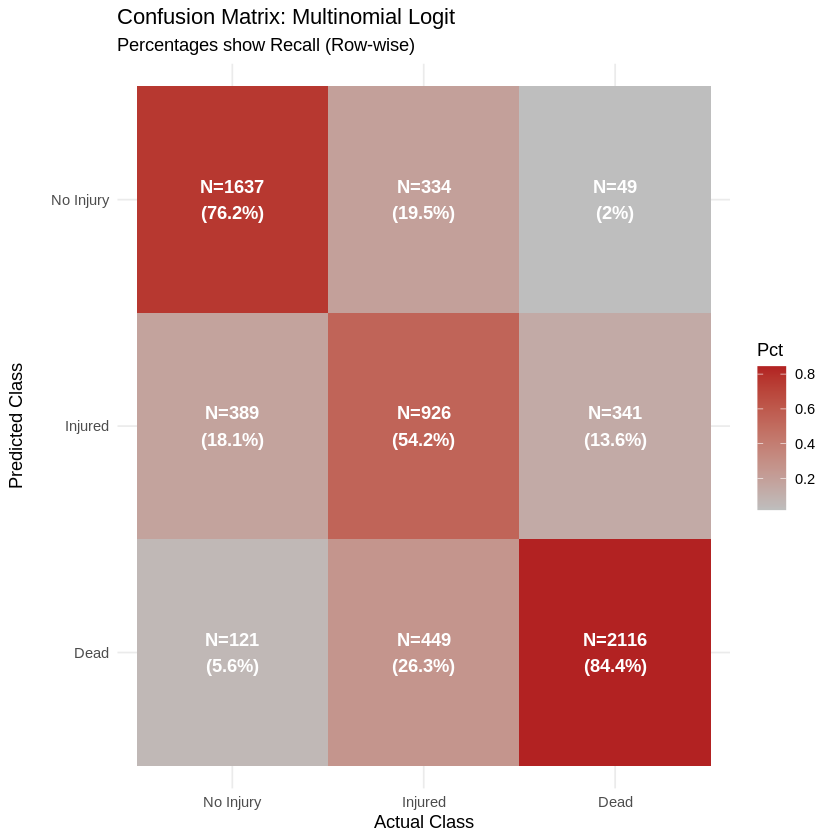

In [ ]:
# --- Fit Multinomial Logit ---
# mlogit <- multinom(INJ_SEV ~ ., data = train_df)

# Summary Statistics
tidy(mlogit, conf.int = TRUE)

# --- Prediction (Argmax) ---
# Predict probabilities on test data
pred_probs <- predict(mlogit, newdata = test_df, type = "probs")

# Predicted class = column (class) with max probability per row
pred_class <- colnames(pred_probs)[max.col(pred_probs)]

# --- Confusion matrix & accuracy ---
cm <- table(Predicted = pred_class,
            Actual = test_df$INJ_SEV)
print(cm)
accuracy <- mean(pred_class == test_df$INJ_SEV)
print(paste("Overall accuracy:", round(accuracy, 3)))

# --- Heatmap: confusion matrix visualization ---
plot_heatmap(test_df$INJ_SEV, pred_class, title_suffix = "Multinomial Logit")



#### Results
performance, loss function used, complexity, bias/variance trade-off, coefficient interpretability (if applicable), limitations

### LASSO

model assumptions, build, etc

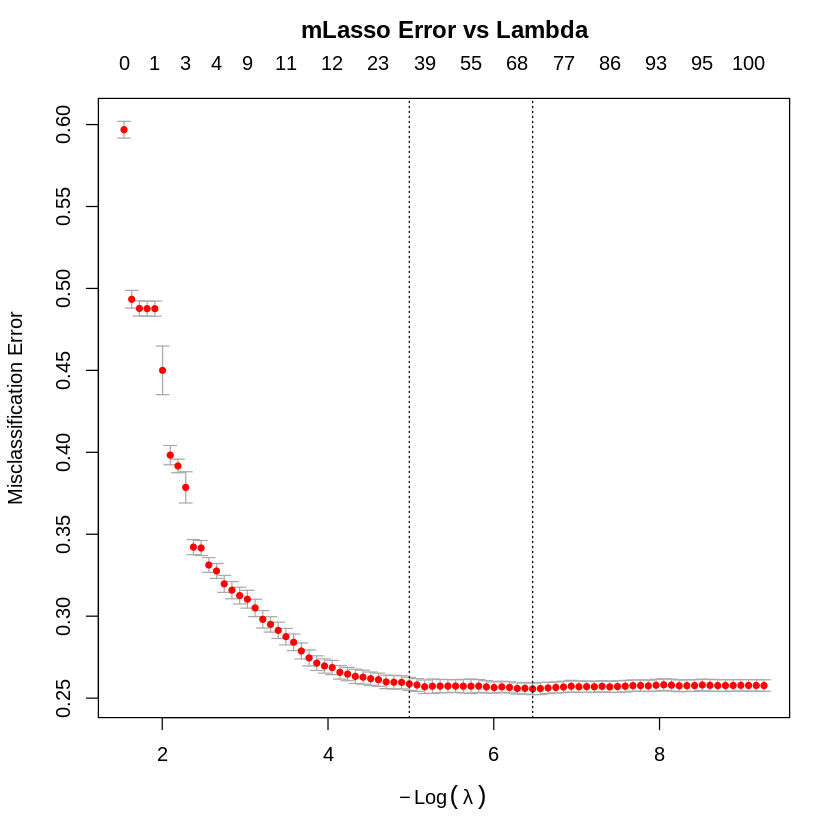

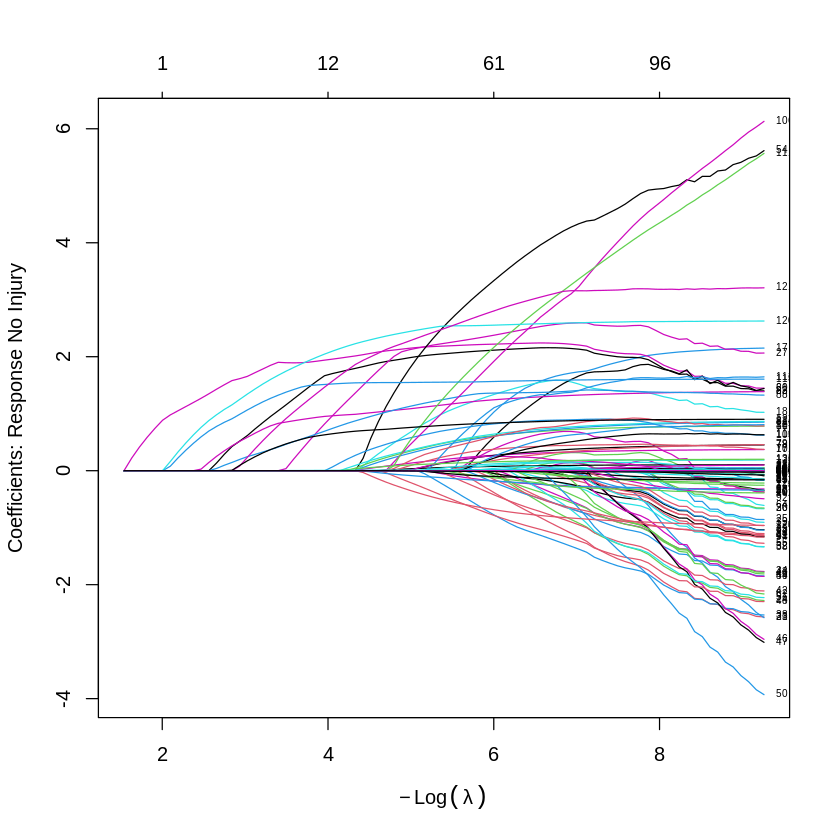

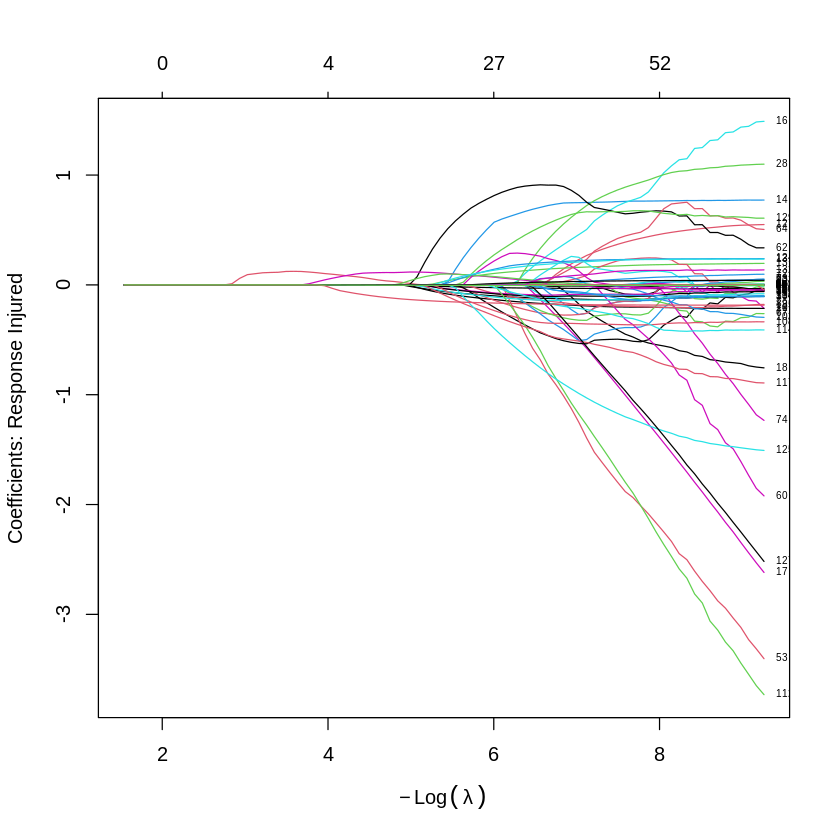

           Actual
Predicted   No Injury Injured Dead
  Dead            122     458 2118
  Injured         391     928  335
  No Injury      1634     323   53
[1] "Overall accuracy: 0.736"


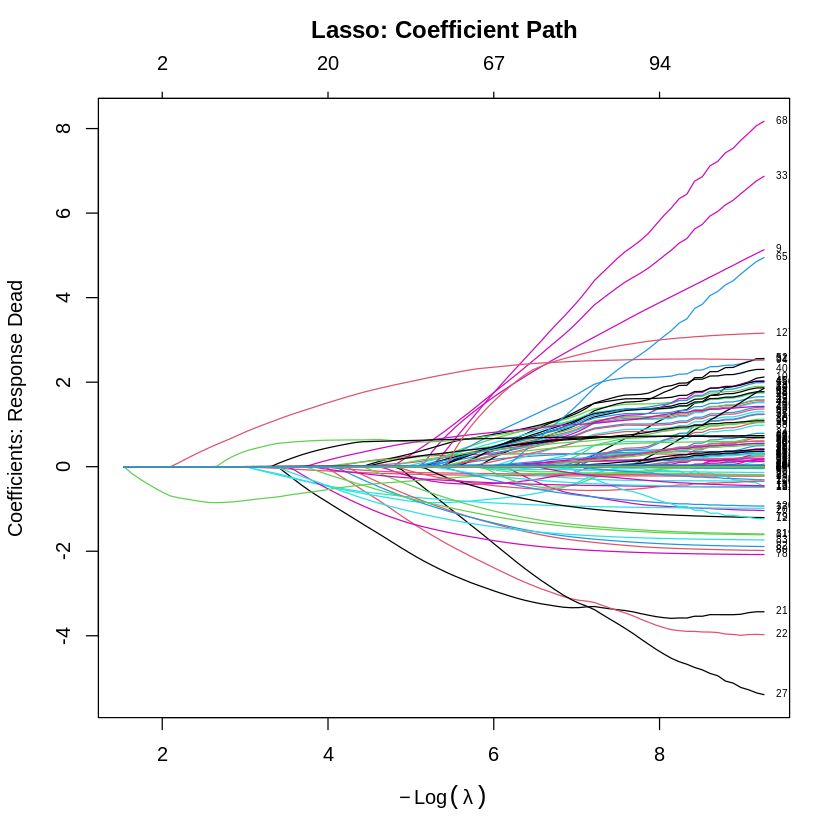

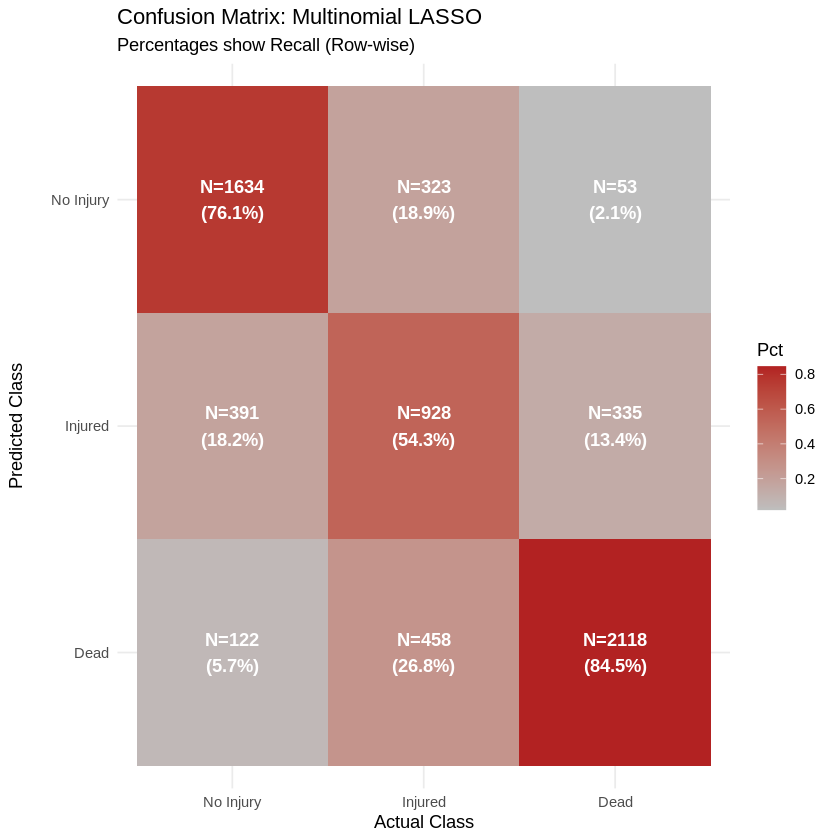

In [ ]:
# --- Fit Multinomial Lasso ---
# family = "multinomial"
# type.measure = "class" shows Misclassification Error on plot
mlasso <- cv.glmnet(X_train_mat, y_train_vec, alpha = 1,
                       family = "multinomial", type.measure = "class")

# Plot Error (for two relative categories) -- death is our baseline (how to choose)
plot(mlasso)
title("mLasso Error vs Lambda", line = 2.5)

# plot coefficient path for death factor?
plot(mlasso$glmnet.fit, xvar = "lambda", label = TRUE)
abline(v = log(mlasso$lambda.min), col = "red", lty = 2)
title("Lasso: Coefficient Path", line = 2.5)

# Prediction (Argmax)
# Predict probabilities on test data
probs_mlasso <- predict(mlasso, newx = X_test_mat,
                       s = "lambda.min", type = "response")[,,1]

# predicted class = column (class) with max probability per row
pred_class <- colnames(probs_mlasso)[max.col(probs_mlasso)]

# confusion matrix, accuracy
cm <- table(Predicted = pred_class, Actual = y_test_vec)
print(cm)
accuracy <- mean(pred_class == y_test_vec)
print(paste("Overall accuracy:", round(accuracy, 3)))

# Heatmap: confusion matrix visualization
plot_heatmap(y_test_vec, pred_class, title_suffix = "Multinomial LASSO")

#### Results
performance, loss function used, complexity, bias/variance trade-off, coefficient interpretability (if applicable)

### Ridge

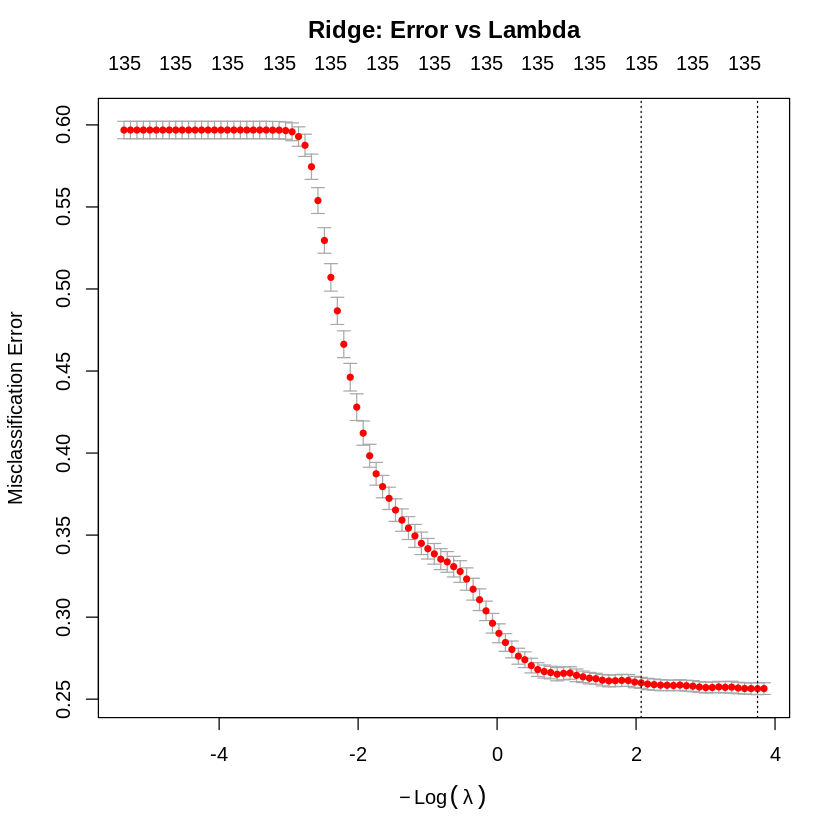

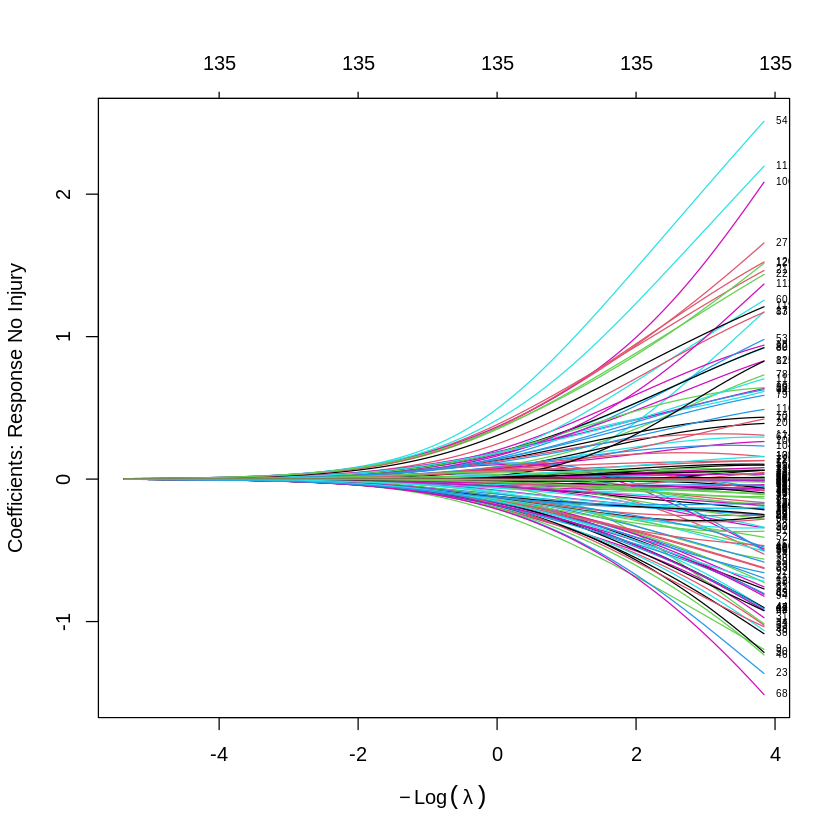

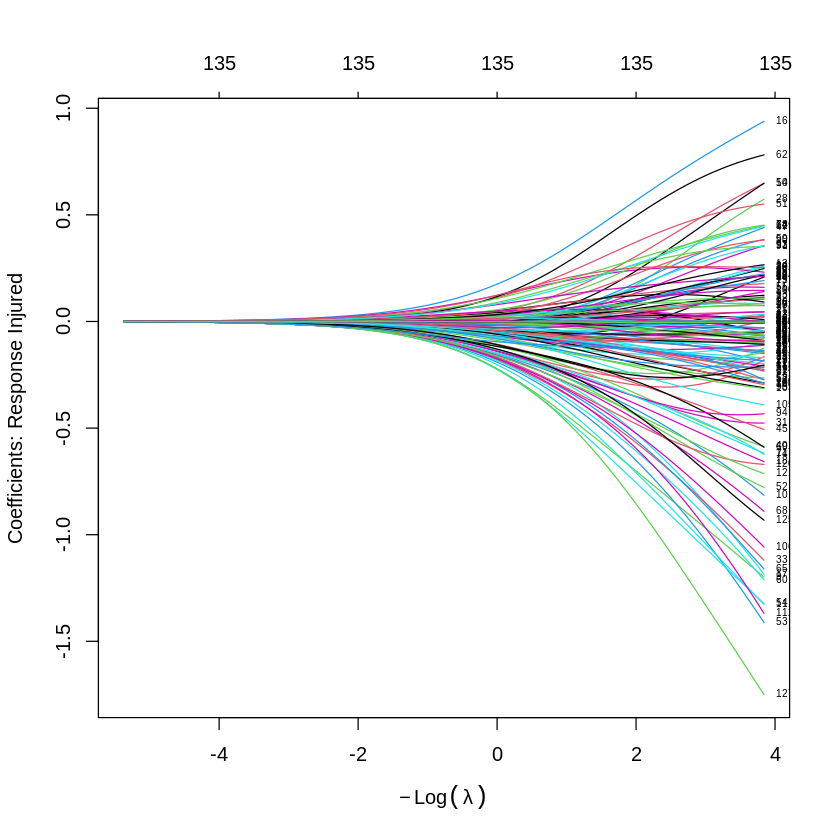

           Actual
Predicted   No Injury Injured Dead
  Dead            127     464 2123
  Injured         381     912  321
  No Injury      1639     333   62
[1] "Overall accuracy: 0.735"


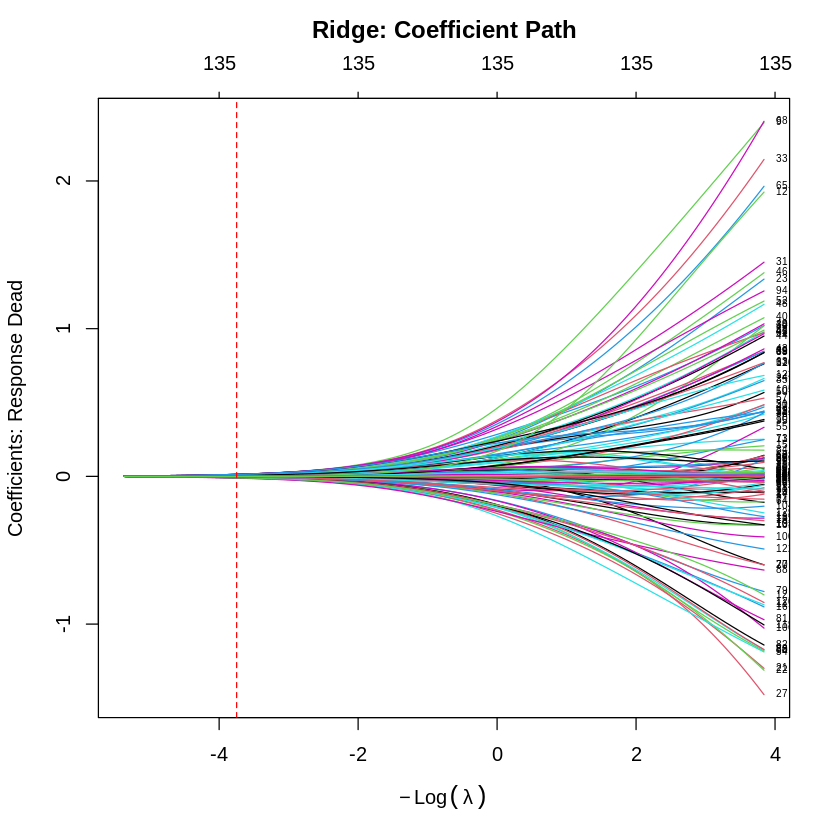

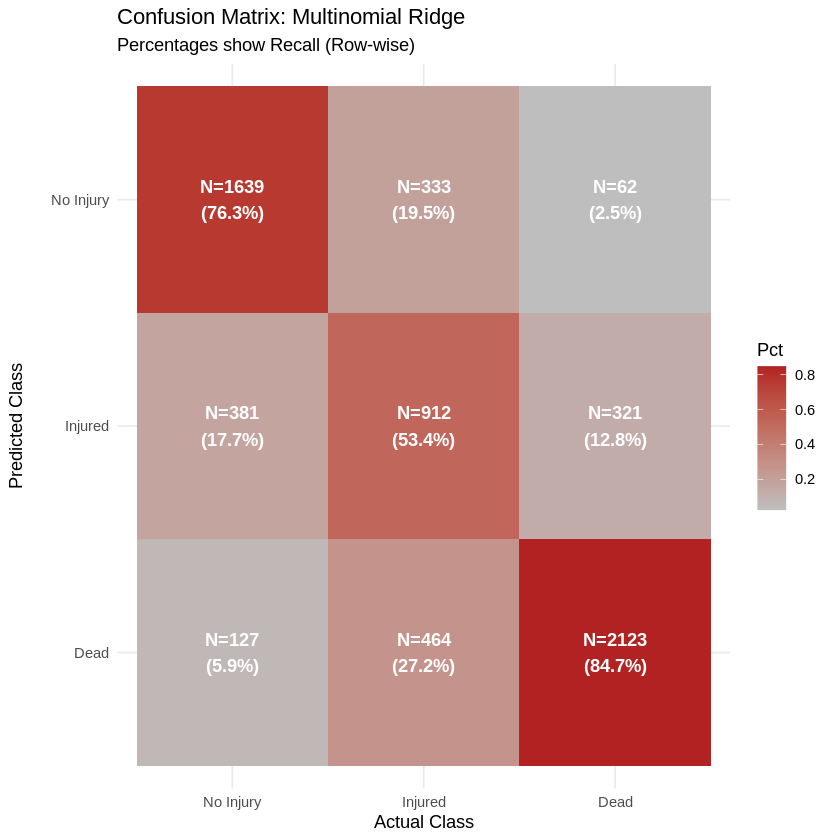

In [ ]:
# --- A. Fit Ridge CV (Alpha = 0) ---
mridge <- cv.glmnet(X_train_mat, y_train_vec,
                         alpha = 0, family = "multinomial",
                         type.measure = "class")

# --- B. Plots ---
# 1. Error vs Lambda
plot(mridge)
title("Ridge: Error vs Lambda", line = 2.5)

# 2. Coefficient Path (Visualizing how coefs shrink)
plot(mridge$glmnet.fit, xvar = "lambda", label = TRUE)
abline(v = log(mridge$lambda.min), col = "red", lty = 2)
title("Ridge: Coefficient Path", line = 2.5)

# Prediction (Argmax)
# Predict probabilities on test data
probs_mridge <- predict(mridge, newx = X_test_mat,
                       s = "lambda.min", type = "response")[,,1]

# predicted class = column (class) with max probability per row
pred_class <- colnames(probs_mridge)[max.col(probs_mridge)]

# confusion matrix, accuracy
cm <- table(Predicted = pred_class, Actual = y_test_vec)
print(cm)
accuracy <- mean(pred_class == y_test_vec)
print(paste("Overall accuracy:", round(accuracy, 3)))

# Heatmap: confusion matrix visualization
plot_heatmap(y_test_vec, pred_class, title_suffix = "Multinomial Ridge")


#### Results
performance, loss function used, complexity, bias/variance trade-off, coefficient interpretability (if applicable)

### kNN

[1] "Best k: 41"
           Actual
Predicted   No Injury Injured Dead
  No Injury      1466     313  114
  Injured         463     890  439
  Dead            218     506 1953
[1] "Overall accuracy: 0.677"


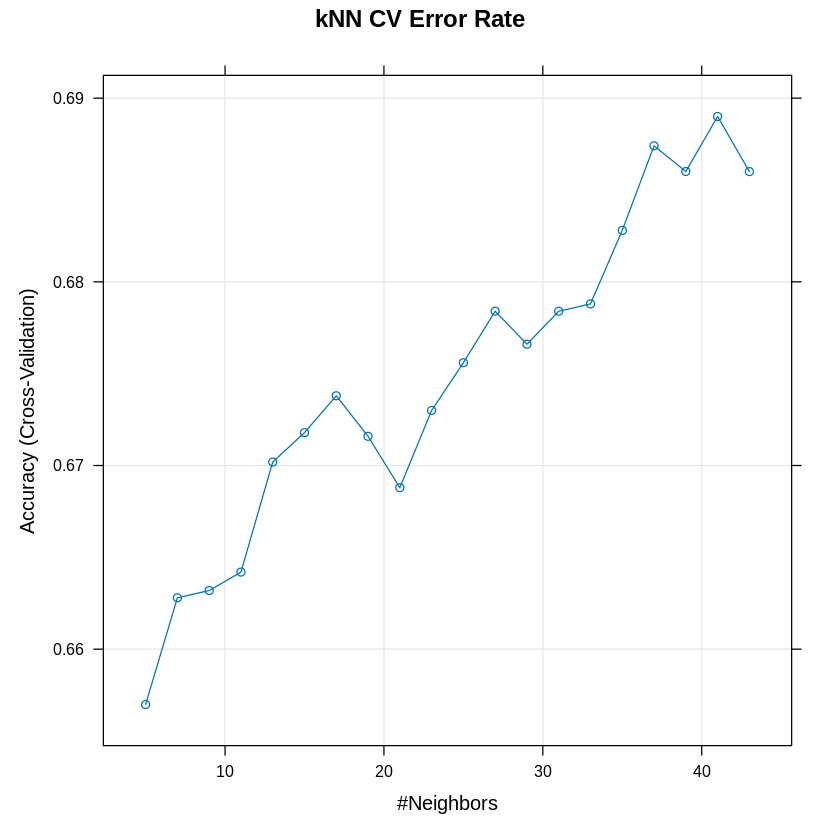

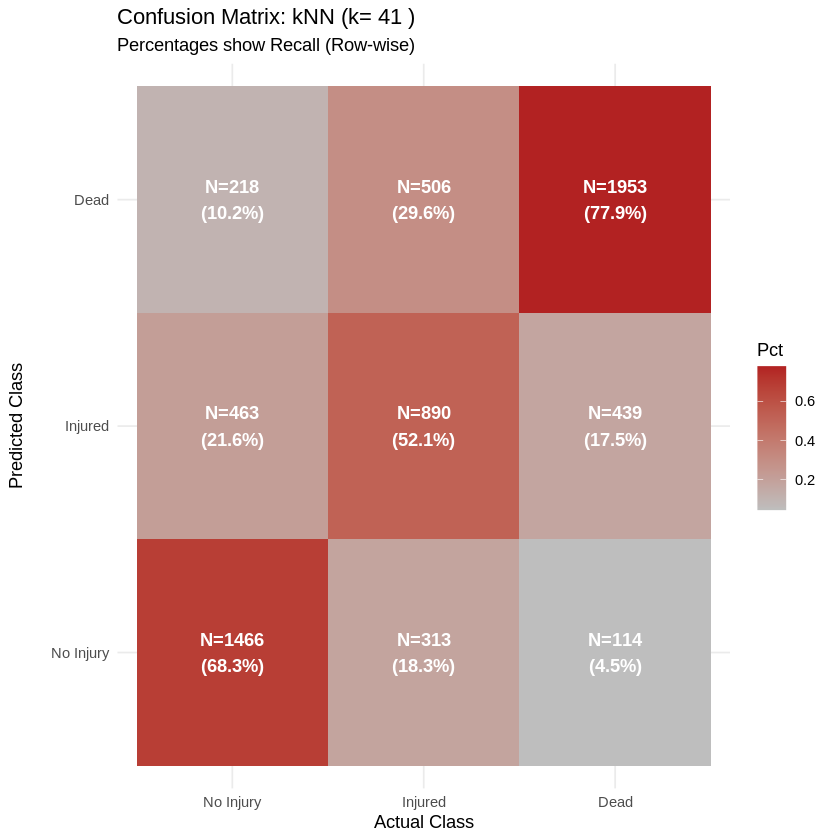

In [ ]:
set.seed(123)
# --- 1. Subsample training set for fast tuning ---
sub_n <- 5000  # 5k rows for tuning
sub_idx <- sample(nrow(X_train_mat), sub_n)
X_train_sub <- X_train_mat[sub_idx, ]
y_train_sub <- y_train_vec[sub_idx]

# --- 2. Scale data ---
X_train_scaled <- scale(X_train_sub)
X_test_scaled  <- scale(X_test_mat,
                        center = attr(X_train_scaled, "scaled:center"),
                        scale = attr(X_train_scaled, "scaled:scale"))

# Remove constant columns
constant_cols <- which(apply(X_train_scaled, 2, function(x) length(unique(x)) == 1))
if(length(constant_cols) > 0){
  X_train_scaled <- X_train_scaled[, -constant_cols]
  X_test_scaled  <- X_test_scaled[, -constant_cols]
}

# --- 3. Find best k using 5-fold CV via caret ---
train_control <- trainControl(method = "cv", number = 5)

knn_fit <- train(
  x = X_train_scaled, y = y_train_sub,
  method = "knn",
  tuneLength = 20,     # tries 20 different k values
  trControl = train_control
)

# --- 4. Plot CV results ---
plot(knn_fit, main = "kNN CV Error Rate")
best_k <- knn_fit$bestTune$k
print(paste("Best k:", best_k))

# --- 5. Train final model on subsample & predict test set ---
knn_pred <- knn(train = X_train_scaled, test = X_test_scaled,
                cl = y_train_sub, k = best_k, prob = TRUE)

# --- 6. Confusion matrix & accuracy ---
cm <- table(Predicted = knn_pred, Actual = y_test_vec)
print(cm)
accuracy <- mean(knn_pred == y_test_vec)
print(paste("Overall accuracy:", round(accuracy, 3)))

# --- 7. Heatmap visualization ---
plot_heatmap(y_test_vec, knn_pred,
             title_suffix = paste("kNN (k=", best_k, ")"))


#### Results
performance, loss function used, complexity, bias/variance trade-off, coefficient interpretability (if applicable)

### Random Forests

In [ ]:
# --- A. Fit Default Model (To check OOB Error) ---
set.seed(123)
# importance = TRUE is needed to get MeanDecreaseAccuracy later
rf_default <- randomForest(INJ_SEV ~ ., data = train_df,
                           ntree = 500, importance = TRUE)

# --- B. Diagnostic 1: Optimal Number of Trees ---
# Plot the OOB Error rate as trees are added
# Black line = Overall OOB Error. Red/Green lines = Error for specific classes.
plot(rf_default, main = "OOB Error vs Number of Trees")
legend("topright", colnames(rf_default$err.rate), col=1:3, fill=1:3)

# findings: Look for where the Black line flattens out.
# If it's flat at 100, you don't need 500 trees. (Saves computation time)

# --- C. Diagnostic 2: Tune 'mtry' (Variables per Split) ---
# mtry is the most critical hyperparameter in RF.
# tuneRF starts at default sqrt(p) and steps up/down to find the minimum OOB error.

set.seed(123)
tune_res <- tuneRF(
  x = train_df %>%
    dplyr::select(-INJ_SEV),
  y = train_df$INJ_SEV,
  ntreeTry = 500,
  stepFactor = 1.5,  # How much to increase mtry at each step
  improve = 0.01,    # Stop if improvement is < 1%
  trace = TRUE,      # Show progress
  plot = TRUE        # Plot OOB error vs mtry
)

# Extract the best mtry value
best_mtry <- tune_res[which.min(tune_res[, 2]), 1]
print(paste("Optimal mtry:", best_mtry))

# --- D. Final Model (Retrain with Optimal Settings) ---
rf_final <- randomForest(INJ_SEV ~ ., data = train_df,
                         ntree = 500, # or lower if plot showed stability earlier
                         mtry = best_mtry,
                         importance = TRUE)

### NOTE: if mtry == num_predictors, rf becomes bagging

# --- E. Diagnostic 3: Variable Importance ---
# 1. Plot the Importance
varImpPlot(rf_final, main = "Variable Importance")

# 2. Access the specific numbers
# - MeanDecreaseAccuracy: How much model accuracy drops if we scramble this variable. (Best for interpretability)
# - MeanDecreaseGini: How much this variable contributes to the homogeneity of the nodes. (Math-heavy)
importance_df <- data.frame(importance(rf_final))
head(importance_df[order(-importance_df$MeanDecreaseAccuracy), ], 5)

# --- F. Standard Evaluation ---
pred_rf <- predict(rf_final, newdata = test_df)
prob_rf <- predict(rf_final, newdata = test_df, type = "prob")[, 2]

print("--- Confusion Matrix (Tuned RF) ---")
print(table(Predicted = pred_rf, Actual = y_test_vec))

plot_heatmap(y_test_vec, pred_rf, title_suffix = "Random Forest (Tuned)")
roc_rf <- roc(y_test_num, prob_rf)
print(paste("AUC:", round(auc(roc_rf), 4)))

ERROR: Error in randomForest.default(m, y, ...): Can not handle categorical predictors with more than 53 categories.


In [ ]:
# If your training data is a data.frame
X_train_df <- as.data.frame(X_train_mat)  # convert matrix to data.frame if needed

# Identify factor columns
factor_cols <- sapply(X_train_df, is.factor)

# Count levels for each factor
n_levels <- sapply(X_train_df[, factor_cols, drop = FALSE], nlevels)

# Print factors with >53 levels
high_card_vars <- n_levels[n_levels > 53]

if(length(high_card_vars) == 0){
  cat("No factors with more than 53 levels. You are safe for randomForest.\n")
} else {
  cat("High-cardinality factors (>53 levels) detected:\n")
  print(high_card_vars)
}



No factors with more than 53 levels. You are safe for randomForest.


#### Results
performance, loss function used, complexity, bias/variance trade-off, coefficient interpretability (if applicable)

## Results
comparing performance across all models -- which is the 'best'

ROC/AUC Curves

In [ ]:
# 1. Gather all ROC objects into a list
# (Ensure you have run all previous sections so these objects exist)
roc_list <- list(
  Logistic      = roc_log,
  Ridge         = roc_ridge,
  Lasso         = roc_lasso,
  kNN           = roc_knn,
  RandomForest  = roc_rf
)

# 2. Extract AUC values
auc_values <- sapply(roc_list, function(x) as.numeric(auc(x)))

# 3. Create a Data Frame
auc_table <- data.frame(
  Model = names(auc_values),
  AUC = round(auc_values, 4)
)

# 4. Sort by AUC (Descending) to see the winner
auc_table_sorted <- auc_table %>%
  arrange(desc(AUC))

# 5. Print the Clean Table
print("--- Final Model Leaderboard (AUC) ---")
print(auc_table_sorted)

ggroc(roc_list, size = 1) +
  geom_abline(slope = 1, intercept = 1, linetype = "dashed", color = "grey") +
  labs(title = "ROC Comparison")  +
  theme_minimal()



Comparing Out-of-Sample Test Error: Misclassification Rate

In [ ]:
set.seed(123)
n <- nrow(data_bin)
k <- 5
folds <- sample(rep(1:k, length.out = n))

# Storage for Error Rates
res_all <- tibble(
  Fold = 1:k,
  Logit = NA,
  Ridge = NA,
  Lasso = NA,
  kNN   = NA,
  Tree  = NA,
  Bag   = NA,
  RF    = NA,
  XGB   = NA
)

print("Starting 5-Fold CV Loop (This may take a minute)...")

for (i in 1:k) {

  # --- A. Define Split ---
  test_idx <- which(folds == i)
  tr <- data_bin[-test_idx, ]
  te <- data_bin[test_idx, ]

  # --- B. Prepare Data Formats ---
  # 1. Matrices (for GLMNET)
  x_tr_mat <- model.matrix(INJ_SEV ~ ., tr)[, -1]
  x_te_mat <- model.matrix(INJ_SEV ~ ., te)[, -1]

  # 2. Scaled Matrices (for kNN - computed inside loop to avoid leakage)
  x_tr_sc <- scale(x_tr_mat)
  # Scale test using TRAIN parameters
  x_te_sc <- scale(x_te_mat, center = attr(x_tr_sc, "scaled:center"),
                             scale = attr(x_tr_sc, "scaled:scale"))

  # 3. Numeric Targets (for XGB/Logit calc)
  y_te_num <- as.numeric(as.character(te$INJ_SEV))

  # --- C. Train & Predict Models ---

  # 1. Multinomial Logit
  m_log <- suppressWarnings(glm(INJ_SEV ~ ., data = tr, family = "binomial"))
  p_log <- ifelse(predict(m_log, newdata = te, type = "response") > 0.5, 1, 0)
  res_all$Logit[i] <- mean(p_log != y_te_num)

  # 2. Ridge
  m_rd <- cv.glmnet(x_tr_mat, tr$INJ_SEV, alpha = 0, family = "binomial")
  p_rd <- predict(m_rd, newx = x_te_mat, s = "lambda.min", type = "class")
  res_all$Ridge[i] <- mean(p_rd != as.character(te$INJ_SEV))

  # 3. Lasso
  m_las <- cv.glmnet(x_tr_mat, tr$INJ_SEV, alpha = 1, family = "binomial")
  p_las <- predict(m_las, newx = x_te_mat, s = "lambda.min", type = "class")
  res_all$Lasso[i] <- mean(p_las != as.character(te$INJ_SEV))

  # 4. k-Nearest Neighbors
  # knn returns a factor, so we compare directly to te$INJ_SEV
  p_knn <- knn(train = x_tr_sc, test = x_te_sc, cl = tr$INJ_SEV, k = best_k)
  res_all$kNN[i] <- mean(p_knn != te$INJ_SEV)

  # 5. Random Forest (Standard)
  m_rf <- randomForest(INJ_SEV ~ ., data = tr, ntree = 100)
  p_rf <- predict(m_rf, newdata = te)
  res_all$RF[i] <- mean(p_rf != te$INJ_SEV)
}

# --- D. Final Leaderboard ---
# Calculate means and sort
final_scores <- colMeans(res_all[, -1]) %>%
  sort() %>%
  as.data.frame()

colnames(final_scores) <- c("Avg_Misclass_Rate")
print("--- Final Model Leaderboard (Misclassification Rate) ---")
print(final_scores)

### Reflection
what could have improved our results? what were some challenges we faced?

### Conclusion